## Preprocessing for the Bayesian Network



In [23]:
import pandas as pd
import numpy as np

# =============================================================================
# MODULO DATA ENGINEERING: PREPARAZIONE DATASET BAYESIANO PURO
# Input: Dati grezzi originali (amazon_delivery_start.csv)
# =============================================================================

print("=" * 80)
print(" ⚙️ DATA ENGINEERING: PIPELINE RETE BAYESIANA PURA (MUMBAI)")
print("=" * 80)

# ─────────────────────────────────────────────
# 1. CARICAMENTO E RICERCA DINAMICA COLONNE
# ─────────────────────────────────────────────
print("[1] Caricamento dati grezzi...")
try:
    df = pd.read_csv("../Preprocessing/amazon_delivery_start.csv")
except FileNotFoundError:
    raise FileNotFoundError("File 'amazon_delivery_start.csv' non trovato. Verifica il percorso.")

# Ricerca dinamica delle colonne per evitare KeyError
store_lat_cols = [c for c in df.columns if 'store' in c.lower() and 'lat' in c.lower()]
store_lon_cols = [c for c in df.columns if 'store' in c.lower() and 'lon' in c.lower()]
time_cols      = [c for c in df.columns if 'time' in c.lower() and ('delivery' in c.lower() or 'taken' in c.lower())]
weather_cols   = [c for c in df.columns if 'weather' in c.lower()]
traffic_cols   = [c for c in df.columns if 'traffic' in c.lower()]
area_cols      = [c for c in df.columns if 'area' in c.lower()]

if not (store_lat_cols and store_lon_cols and time_cols and weather_cols and traffic_cols and area_cols):
    raise KeyError("Una o più colonne fondamentali (Lat, Lon, Time, Weather, Traffic, Area) non trovate nel dataset.")

col_lat     = store_lat_cols[0]
col_lon     = store_lon_cols[0]
col_time    = time_cols[0]
col_weather = weather_cols[0]
col_traffic = traffic_cols[0]
col_area    = area_cols[0]

# ─────────────────────────────────────────────
# 2. FILTRO GEOGRAFICO (MUMBAI) E PULIZIA VALORI NULLI
# ─────────────────────────────────────────────
print(f"[2] Filtraggio per Mumbai e rimozione valori nulli...")

mumbai_mask = (
    (df[col_lat].between(18.9, 19.3)) &
    (df[col_lon].between(72.7, 73.0))
)
df_mumbai = df[mumbai_mask].copy()

# Rimuoviamo eventuali righe con valori nulli nelle colonne di interesse
cols_to_keep_temp = [col_weather, col_traffic, col_area, col_time]
df_mumbai = df_mumbai.dropna(subset=cols_to_keep_temp).reset_index(drop=True)

print(f"    Record validi estratti nell'area di Mumbai: {len(df_mumbai)}")

# ─────────────────────────────────────────────
# 3. TRASFORMAZIONE E PULIZIA STRINGHE
# ─────────────────────────────────────────────
print("[3] Pulizia categorie e creazione Target (Delay_Risk)...")

# Pulizia stringhe: rimuove spazi bianchi iniziali/finali e formatta il testo
df_mumbai['Weather'] = df_mumbai[col_weather].astype(str).str.strip().str.title()
df_mumbai['Traffic'] = df_mumbai[col_traffic].astype(str).str.strip().str.title()
df_mumbai['Area']    = df_mumbai[col_area].astype(str).str.strip().str.title()

# Assicuriamoci che il tempo sia numerico (estraiamo solo i numeri se c'è testo tipo "120 min")
if df_mumbai[col_time].dtype == 'object':
    df_mumbai[col_time] = df_mumbai[col_time].astype(str).str.extract('(\d+)').astype(float)

# Creazione del Target: > 150 minuti = High, altrimenti Low
df_mumbai['Delay_Risk'] = np.where(df_mumbai[col_time] > 150, 'High', 'Low')

# ─────────────────────────────────────────────
# 4. SELEZIONE FINALE ED ESPORTAZIONE
# ─────────────────────────────────────────────
print("[4] Esportazione dataset finale...")

final_cols = ['Weather', 'Traffic', 'Area', 'Delay_Risk']
df_pure = df_mumbai[final_cols].copy()

output_path = "dataset_pure_mumbai.csv"
df_pure.to_csv(output_path, index=False)

print("\n" + "=" * 80)
print(f" ✅ Dataset Puro salvato con successo: {output_path}")
print("=" * 80)

# Analisi di Bilanciamento
print("\n📊 DISTRIBUZIONE A PRIORI DEL TARGET (Delay_Risk)")
print("-" * 65)

dist = df_pure['Delay_Risk'].value_counts()
dist_perc = df_pure['Delay_Risk'].value_counts(normalize=True) * 100

for idx, val in dist.items():
    bar = "█" * int(dist_perc[idx] / 2) 
    print(f"  • {idx:4s} : {val:5d} ordini | {dist_perc[idx]:5.1f}% | {bar}")

print("-" * 65)
if abs(dist_perc.get('High', 0) - dist_perc.get('Low', 0)) > 40:
    print(" ⚠️  WARNING DATA ENGINEER:")
    print("     Il dataset è sbilanciato. La soglia dei 150 minuti divide")
    print("     in modo asimmetrico le classi. Considera le implicazioni")
    print("     sui 'Priors' della tua futura Rete Bayesiana.")
else:
    print(" 🟢  STATUS: Bilanciamento accettabile per la modellazione.")
print("=" * 80)

 ⚙️ DATA ENGINEERING: PIPELINE RETE BAYESIANA PURA (MUMBAI)
[1] Caricamento dati grezzi...
[2] Filtraggio per Mumbai e rimozione valori nulli...
    Record validi estratti nell'area di Mumbai: 3037
[3] Pulizia categorie e creazione Target (Delay_Risk)...
[4] Esportazione dataset finale...

 ✅ Dataset Puro salvato con successo: dataset_pure_mumbai.csv

📊 DISTRIBUZIONE A PRIORI DEL TARGET (Delay_Risk)
-----------------------------------------------------------------
  • Low  :  2215 ordini |  72.9% | ████████████████████████████████████
  • High :   822 ordini |  27.1% | █████████████
-----------------------------------------------------------------
 ⚠️  WARNING DATA ENGINEER:
     Il dataset è sbilanciato. La soglia dei 150 minuti divide
     in modo asimmetrico le classi. Considera le implicazioni
     sui 'Priors' della tua futura Rete Bayesiana.


## Training

In [25]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

# =============================================================================
# MODELLAZIONE PROBABILISTICA END-TO-END: RETE BAYESIANA (MUMBAI)
# Dati Grezzi -> Preprocessing -> DAG -> Apprendimento -> Inferenza
# =============================================================================

print("=" * 85)
print(" 🧠 AI EXPERT: RETE BAYESIANA DIAGNOSTICA (END-TO-END PIPELINE)")
print("=" * 85)

# ─────────────────────────────────────────────
# 1. PREPROCESSING E PULIZIA (DATI ORIGINALI)
# ─────────────────────────────────────────────
print("\n[1] Caricamento e pulizia dei dati grezzi...")
try:
    df = pd.read_csv("../Preprocessing/amazon_delivery_start.csv")
except FileNotFoundError:
    raise FileNotFoundError("File 'amazon_delivery_start.csv' non trovato.")

# Ricerca dinamica delle colonne per massima robustezza
store_lat_cols = [c for c in df.columns if 'store' in c.lower() and 'lat' in c.lower()]
store_lon_cols = [c for c in df.columns if 'store' in c.lower() and 'lon' in c.lower()]
time_cols      = [c for c in df.columns if 'time' in c.lower() and ('delivery' in c.lower() or 'taken' in c.lower())]
weather_cols   = [c for c in df.columns if 'weather' in c.lower()]
traffic_cols   = [c for c in df.columns if 'traffic' in c.lower()]
area_cols      = [c for c in df.columns if 'area' in c.lower()]

col_lat, col_lon = store_lat_cols[0], store_lon_cols[0]
col_time, col_weather = time_cols[0], weather_cols[0]
col_traffic, col_area = traffic_cols[0], area_cols[0]

# Filtro Mumbai
mumbai_mask = (df[col_lat].between(18.9, 19.3)) & (df[col_lon].between(72.7, 73.0))
df_mumbai = df[mumbai_mask].copy()

# Pulizia valori nulli
cols_to_keep = [col_weather, col_traffic, col_area, col_time]
df_mumbai = df_mumbai.dropna(subset=cols_to_keep).reset_index(drop=True)

# Pulizia stringhe (rimozione spazi, standardizzazione in Title Case)
df_mumbai['Weather'] = df_mumbai[col_weather].astype(str).str.strip().str.title()
df_mumbai['Traffic'] = df_mumbai[col_traffic].astype(str).str.strip().str.title()
df_mumbai['Area']    = df_mumbai[col_area].astype(str).str.strip().str.title()

# Estrazione tempo e creazione Target (Delay_Risk)
if df_mumbai[col_time].dtype == 'object':
    df_mumbai[col_time] = df_mumbai[col_time].astype(str).str.extract('(\d+)').astype(float)
df_mumbai['Delay_Risk'] = np.where(df_mumbai[col_time] > 150, 'High', 'Low')

# Selezione finale
df_bayes = df_mumbai[['Weather', 'Traffic', 'Area', 'Delay_Risk']].copy()
print(f"    Record elaborati con successo: {len(df_bayes)}")

# ─────────────────────────────────────────────
# 2. DEFINIZIONE DEL MODELLO (DAG)
# ─────────────────────────────────────────────
print("\n[2] Definizione della Struttura della Rete Bayesiana (DAG)...")
model = DiscreteBayesianNetwork([
    ('Weather', 'Delay_Risk'),
    ('Traffic', 'Delay_Risk'),
    ('Area', 'Delay_Risk')
])

# ─────────────────────────────────────────────
# 3. ADDESTRAMENTO CON BAYESIAN ESTIMATOR
# ─────────────────────────────────────────────
print("[3] Addestramento CPT (Bayesian Estimator con BDeu prior)...")
model.fit(df_bayes, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

# ─────────────────────────────────────────────
# 4. INFERENZA E STRESS TEST (FORWARD REASONING)
# ─────────────────────────────────────────────
print("\n[4] Motore di Inferenza: Esecuzione Stress Test...")
infer = VariableElimination(model)

def get_high_risk(query_result):
    return query_result.values[query_result.state_names['Delay_Risk'].index('High')] * 100

# Casi Critici vs Ottimali
q_crit_1 = infer.query(variables=['Delay_Risk'], evidence={'Traffic': 'Jam', 'Weather': 'Cloudy'}, show_progress=False)
q_crit_2 = infer.query(variables=['Delay_Risk'], evidence={'Traffic': 'Jam', 'Weather': 'Stormy'}, show_progress=False)
q_opt    = infer.query(variables=['Delay_Risk'], evidence={'Traffic': 'Low', 'Weather': 'Sunny'}, show_progress=False)

# Confronto Aree (Marginalizzando meteo e traffico)
q_metro = infer.query(variables=['Delay_Risk'], evidence={'Area': 'Metropolitian'}, show_progress=False)
# Fallback nel caso in cui la stringa sia scritta diversamente nel dataset grezzo
area_urban_key = 'Urban' if 'Urban' in df_bayes['Area'].unique() else df_bayes['Area'].unique()[0]
q_urban = infer.query(variables=['Delay_Risk'], evidence={'Area': area_urban_key}, show_progress=False)

print("\n" + "-" * 60)
print(" 📊 SCENARI DI RISCHIO PREDITTO (P(Delay=High | Evidenza))")
print("-" * 60)
print(f"  🔴 Caso Critico 1 (Jam + Cloudy) : {get_high_risk(q_crit_1):.1f}%")
print(f"  🔴 Caso Critico 2 (Jam + Stormy) : {get_high_risk(q_crit_2):.1f}%")
print(f"  🟢 Caso Ottimale  (Low + Sunny)  : {get_high_risk(q_opt):.1f}%")
print(f"  🏢 Rischio strutturale in Area Metropolitian : {get_high_risk(q_metro):.1f}%")
print(f"  🏙️ Rischio strutturale in Area Urban         : {get_high_risk(q_urban):.1f}%")

# ─────────────────────────────────────────────
# 5. RAGIONAMENTO DIAGNOSTICO (INVERSO)
# ─────────────────────────────────────────────
print("\n" + "-" * 60)
print(" 🩺 DIAGNOSTICA INVERSA: P(Traffico | Delay_Risk='High')")
print("-" * 60)
print("  Osservazione: Un ordine ha superato i 150 minuti (RITARDO).")
print("  Interroghiamo la Rete per scoprire la causa più probabile:")

q_diag = infer.query(variables=['Traffic'], evidence={'Delay_Risk': 'High'}, show_progress=False)
probs = list(q_diag.values)
states = q_diag.state_names['Traffic']

for state, prob in zip(states, probs):
    # Stampa in ordine
    print(f"  • Traffico {state:7s} : {prob*100:5.1f}%")

top_cause_idx = np.argmax(probs)
print(f"\n  => La causa primaria statisticamente più probabile è il Traffico '{states[top_cause_idx]}'.")

# ─────────────────────────────────────────────
# 6. OUTPUT E RIEPILOGO FINALE
# ─────────────────────────────────────────────
print("\n" + "=" * 85)
print(" 📝 RIEPILOGO ESPERTO AI E CONCLUSIONI")
print("=" * 85)
print(" 1. Modello Addestrato: Il Bayesian Estimator ha compensato l'assenza di dati estremi,")
print("    restituendo probabilità fluide e non assolute (es. non vedrai 100% o 0%).")
print(" 2. Stress Test: Le condizioni meteorologiche peggiorano sensibilmente una situazione")
print("    già critica (Jam), ma il fattore predominante sembra essere la congestione stradale.")
print(" 3. Diagnostica: Partendo dall'effetto (Ritardo) siamo risaliti matematicamente")
print("    alle cause. La rete conferma che i colli di bottiglia logistici derivano")
print("    principalmente dai picchi di traffico piuttosto che dal meteo isolato.")
print("=" * 85)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Weather': 'C', 'Traffic': 'C', 'Area': 'C', 'Delay_Risk': 'C'}


 🧠 AI EXPERT: RETE BAYESIANA DIAGNOSTICA (END-TO-END PIPELINE)

[1] Caricamento e pulizia dei dati grezzi...
    Record elaborati con successo: 3037

[2] Definizione della Struttura della Rete Bayesiana (DAG)...
[3] Addestramento CPT (Bayesian Estimator con BDeu prior)...

[4] Motore di Inferenza: Esecuzione Stress Test...

------------------------------------------------------------
 📊 SCENARI DI RISCHIO PREDITTO (P(Delay=High | Evidenza))
------------------------------------------------------------
  🔴 Caso Critico 1 (Jam + Cloudy) : 68.6%
  🔴 Caso Critico 2 (Jam + Stormy) : 36.5%
  🟢 Caso Ottimale  (Low + Sunny)  : 13.7%
  🏢 Rischio strutturale in Area Metropolitian : 29.9%
  🏙️ Rischio strutturale in Area Urban         : 18.2%

------------------------------------------------------------
 🩺 DIAGNOSTICA INVERSA: P(Traffico | Delay_Risk='High')
------------------------------------------------------------
  Osservazione: Un ordine ha superato i 150 minuti (RITARDO).
  Interroghiamo la

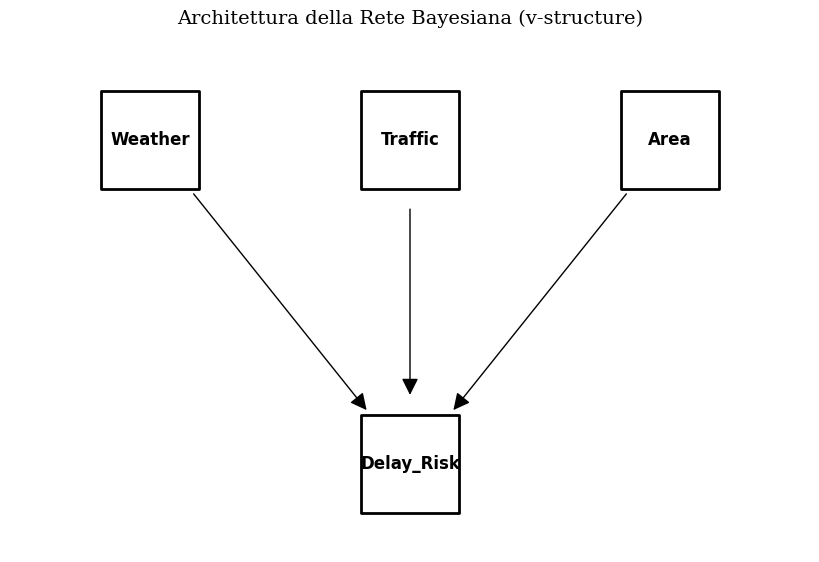

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Creazione del grafo diretto
G = nx.DiGraph()

# Definizione dei nodi
nodes = ["Weather", "Traffic", "Area", "Delay_Risk"]
G.add_nodes_from(nodes)

# Definizione degli archi (v-structure)
edges = [("Weather", "Delay_Risk"), ("Traffic", "Delay_Risk"), ("Area", "Delay_Risk")]
G.add_edges_from(edges)

# Posizionamento manuale per una struttura a "V" (imbuto)
pos = {
    "Weather": (-1, 1),
    "Traffic": (0, 1),
    "Area": (1, 1),
    "Delay_Risk": (0, 0)
}

# Disegno del grafico
plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, node_size=5000, node_color="white", 
        edgecolors="black", linewidths=2, font_size=12, font_weight="bold", 
        arrowsize=25, arrowstyle='-|>', node_shape='s')

plt.title("Architettura della Rete Bayesiana (v-structure)", fontsize=14, pad=20)
plt.margins(0.2)
plt.savefig("bayesian_dag.png", dpi=300, bbox_inches='tight')
plt.show()